# Кластеризация

В этом домашнем задании предлагается реализовать три различных метода кластеризации, понять, в каких случаях стоит применять те или иные методы, а так же применить один из алгоритмов к задаче уменьшения цветности изображения.

In [1]:
import inspect
import random
from abc import ABC
from typing import Callable, Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
from numpy import ndarray
from PIL import Image
from sklearn.datasets import make_blobs, make_moons
from sklearn.neighbors import KDTree

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)


# Этой функцией будут помечены все места, которые необходимо дозаполнить
# Это могут быть как целые функции, так и отдельные части внутри них
# Всегда можно воспользоваться интроспекцией и найти места использования этой функции :)
def todo():
    stack = inspect.stack()
    caller_frame = stack[1]
    function_name = caller_frame.function
    line_number = caller_frame.lineno
    raise NotImplementedError(f"TODO at {function_name}, line {line_number}")


SEED = 0xC0FFEE
set_seed(SEED)

In [3]:
def visualize_clusters(X, labels):
    unique_labels = np.unique(labels)
    unique_colors = np.random.random((len(unique_labels), 3))
    colors = [unique_colors[l] for l in labels]
    plt.figure(figsize=(9, 9))
    plt.scatter(X[:, 0], X[:, 1], c=colors)
    plt.show()


def clusters_statistics(flatten_image, cluster_colors, cluster_labels):
    fig, axes = plt.subplots(3, 2, figsize=(12, 16))
    for remove_color in range(3):
        axes_pair = axes[remove_color]
        first_color = 0 if remove_color != 0 else 2
        second_color = 1 if remove_color != 1 else 2
        axes_pair[0].scatter(
            [p[first_color] for p in flatten_image],
            [p[second_color] for p in flatten_image],
            c=flatten_image,
            marker=".",
        )
        axes_pair[1].scatter(
            [p[first_color] for p in flatten_image],
            [p[second_color] for p in flatten_image],
            c=[cluster_colors[c] for c in cluster_labels],
            marker=".",
        )
        for a in axes_pair:
            a.set_xlim(0, 1)
            a.set_ylim(0, 1)
    plt.show()

Генерируем два синтетических набора данных для кластеризации. Далее будем тестировать наши алгоритмы на них.

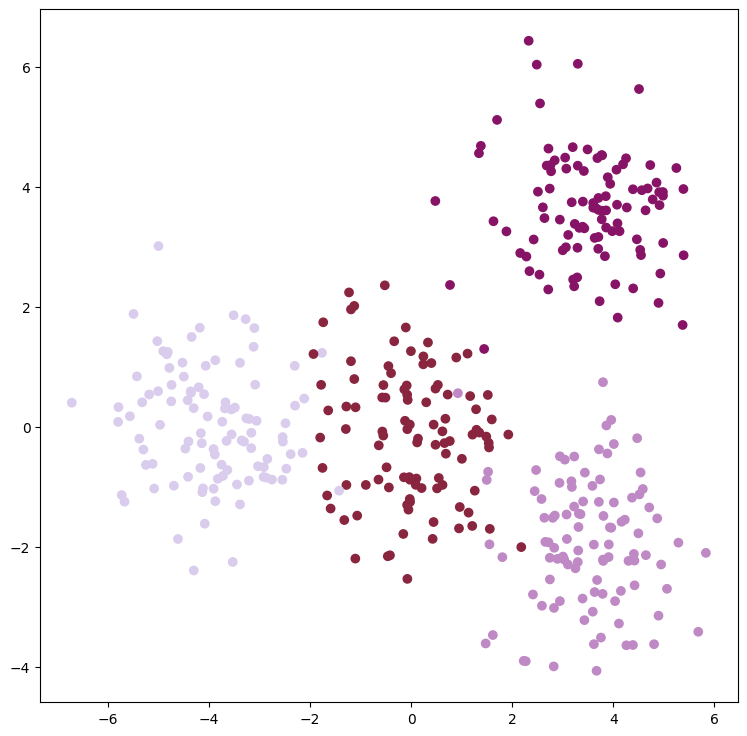

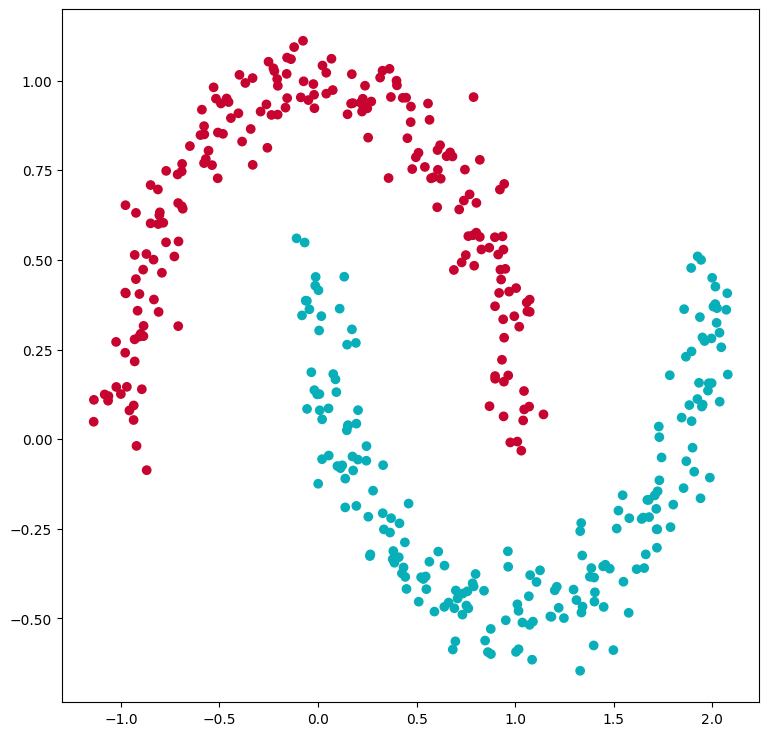

In [4]:
X_1, true_labels = make_blobs(400, 2, centers=[[0, 0], [-4, 0], [3.5, 3.5], [3.5, -2.0]])
visualize_clusters(X_1, true_labels)
X_2, true_labels = make_moons(400, noise=0.075)
visualize_clusters(X_2, true_labels)

Также реализуем необходимые функции для вычисления расстояний между точками

In [5]:
def get_euclidean_distances(from_points: ndarray, to_points: ndarray) -> ndarray:
    """Calculate euclidian distance between points

    Args:
        from_points: array of [source_points; dim] points
        to_points: array of [target_points; dim] points

    Returns:
        distances: array of [source_points; target_points]
    """
    if from_points.shape[0] == 0 or to_points.shape[0] == 0:
        return np.empty((from_points.shape[0], to_points.shape[0]))

    diff = from_points[:, np.newaxis, :] - to_points[np.newaxis, :, :]

    distances = np.sqrt(np.sum(diff ** 2, axis=2))
    return distances


def get_manhattan_distances(from_points: ndarray, to_points: ndarray) -> ndarray:
    """Calculate manhattan distance between points

    Args:
        from_points: array of [source_points; dim] points
        to_points: array of [target_points; dim] points

    Returns:
        distances: array of [source_points; target_points]
    """
    
    if from_points.shape[0] == 0 or to_points.shape[0] == 0:
        return np.empty((from_points.shape[0], to_points.shape[0]))

    diff = from_points[:, np.newaxis, :] - to_points[np.newaxis, :, :]
    
    distances = np.sum(np.abs(diff), axis=2)
    return distances


def get_chebyshev_distance(from_points: ndarray, to_points: ndarray) -> ndarray:
    """Calculate chebyshev distance between points

    Args:
        from_points: array of [source_points; dim] points
        to_points: array of [target_points; dim] points

    Returns:
        distances: array of [source_points; target_points]
    """
    if from_points.shape[0] == 0 or to_points.shape[0] == 0:
        return np.empty((from_points.shape[0], to_points.shape[0]))

    diff = from_points[:, np.newaxis, :] - to_points[np.newaxis, :, :]

    distances = np.max(np.abs(diff), axis=2)
    return distances

## K-Means (3 балла)
Первый метод, который предлагается реализовать - метод K средних.

**Описание методов**

`fit(X, y=None)` ищет и запоминает в `self.centroids` центроиды кластеров для набора данных.

`predict(X)` для каждого элемента из `X` возвращает номер кластера, к которому относится данный элемент.

### Инициализация кластеров
Есть несколько вариантов инициализации кластеров. Нужно реализовать их все:
1. `random` - центроиды кластеров являются случайными точками
2. `sample` - центроиды кластеров выбираются случайно из набора данных
3. `k-means++` - центроиды кластеров инициализируются при помощи метода K-means++

Не забудьте реинициализировать пустые кластеры!

In [6]:
class AbstractCentroidBuilder(ABC):
    name: str = None

    def _generate_centroids(self, x: ndarray, k: int) -> ndarray:
        """Generating centroids from points

        Args:
            x: array of [n_points; dim] points
            k: number of centroids to generate

        """
        raise NotImplementedError()

    @staticmethod
    def _validate_centroids(x: ndarray, centroids: ndarray) -> bool:
        """Validating that each centroid has at least one point next to it"""
        if centroids.shape[0] == 0:
            return True
        if x.shape[0] == 0 and centroids.shape[0] > 0:
            return False

        distances = get_euclidean_distances(x, centroids)
        closest_centroid_indices = np.argmin(distances, axis=1)
        unique_assigned_centroids = np.unique(closest_centroid_indices)
        return len(unique_assigned_centroids) == centroids.shape[0]

    def build(self, x: ndarray, k: int) -> ndarray:
        if k <= 0:
            raise ValueError("Number of centroids (k) must be positive.")
        if x.shape[0] == 0 and k > 0:
            raise ValueError("Cannot generate centroids from empty data.")

        centroids = self._generate_centroids(x, k)
        if self._validate_centroids(x, centroids):
            return centroids


class RandomCentroidBuilder(AbstractCentroidBuilder):
    name: str = "random"

    def _generate_centroids(self, x: ndarray, k: int) -> ndarray:
        n_points, dim = x.shape
        min_vals = np.min(x, axis=0)
        max_vals = np.max(x, axis=0)

        centroids = np.empty((k, dim))
        for i in range(dim):
            centroids[:, i] = np.random.uniform(min_vals[i], max_vals[i], k)
        return centroids


class SampleCentroidBuilder(AbstractCentroidBuilder):
    name: str = "sample"

    def _generate_centroids(self, x: ndarray, k: int) -> ndarray:
        n_points = x.shape[0]
        if k > n_points:
            raise ValueError(f"Cannot sample {k} centroids from {n_points} points.")

        random_indices = np.random.choice(n_points, size=k, replace=False)
        centroids = x[random_indices]
        return centroids


class KMeansPlusCentroidBuilder(AbstractCentroidBuilder):
    name: str = "kmeans++"

    def _generate_centroids(self, x: ndarray, k: int) -> ndarray:
        n_points, dim = x.shape
        if k > n_points:
            raise ValueError(f"Cannot sample {k} centroids from {n_points} points for KMeans++.")

        centroids = np.empty((k, dim))

        first_centroid_idx = np.random.choice(n_points)
        centroids[0] = x[first_centroid_idx]

        if k == 1:
            return centroids

        min_sq_distances = np.full(n_points, np.inf)

        for i in range(1, k):
            sq_distances_to_newest_centroid = get_euclidean_distances(x, centroids[i-1:i])[:, 0] ** 2
            min_sq_distances = np.minimum(min_sq_distances, sq_distances_to_newest_centroid)

            probabilities = min_sq_distances / np.sum(min_sq_distances)
            probabilities_sum = np.sum(probabilities)

            if probabilities_sum == 0 or np.isnan(probabilities_sum):
                cumulative_probs = np.arange(1, n_points + 1) / n_points
            else:
                cumulative_probs = np.cumsum(probabilities)
            
            r = np.random.rand()
            next_centroid_idx = np.searchsorted(cumulative_probs, r)
            
            next_centroid_idx = min(next_centroid_idx, n_points - 1)
            centroids[i] = x[next_centroid_idx]

        return centroids


In [7]:
class KMeans:
    _known_centroid_builders: Dict[str, AbstractCentroidBuilder.__class__] = {
        RandomCentroidBuilder.name: RandomCentroidBuilder,
        SampleCentroidBuilder.name: SampleCentroidBuilder,
        KMeansPlusCentroidBuilder.name: KMeansPlusCentroidBuilder,
    }

    _centroids: ndarray = None
    _x: ndarray = None
    _clusters_ids: ndarray = None

    def __init__(self, n_clusters: int, init: str = "random", tol: float = 1e-4, max_iter: int = 300):
        """KMeans clusterization

        Args:
            n_clusters: number of clusters
            init: strategy to initialize clusters, one of "random", "sample", and "k-means++"
            max_iter: maximum number of iterations
        """
        self._n_clusters = n_clusters
        self._max_iter = max_iter
        self._tol = tol
        if init not in self._known_centroid_builders:
            raise ValueError(f"Unknown way to initialize clusters centroids: {init}")
        self._centroid_builder = self._known_centroid_builders[init]()

    def fit(self, x: ndarray, y: ndarray = None):
        """Build centroids based on X

        Args:
            x: input points, array of [n_points; dim]
            y: ignored, to mactch sklearn behaviour
        """
        n_points, n_features = x.shape
        current_centroids = self._centroid_builder.build(x, self._n_clusters)
        
        assigned_cluster_ids = np.full(n_points, -1, dtype=int)

        for iteration in range(self._max_iter):
            distances_to_centroids = get_euclidean_distances(x, current_centroids)
            new_assigned_cluster_ids = np.argmin(distances_to_centroids, axis=1)

            if np.array_equal(new_assigned_cluster_ids, assigned_cluster_ids):
                break 

            
            assigned_cluster_ids = new_assigned_cluster_ids.copy() # .copy() важен!

            new_centroids = np.zeros((self._n_clusters, n_features))
            centroids_changed_significantly = False
            
            for k in range(self._n_clusters):
                points_in_cluster_k = x[assigned_cluster_ids == k]
                if len(points_in_cluster_k) > 0:
                    new_centroids[k] = np.mean(points_in_cluster_k, axis=0)
                else:
                    new_centroids[k] = current_centroids[k] 

            centroid_shifts = np.sum((new_centroids - current_centroids)**2, axis=None)
            if centroid_shifts < self._tol:
                current_centroids = new_centroids
                break
            
            current_centroids = new_centroids

        self._centroids = current_centroids
        self._cluster_ids_for_x_fit = assigned_cluster_ids

        return self
            

    def predict(self, x: np.array) -> np.array:
        """For each element of input returns corresponding cluster index

        Args:
            x: input points, array of [n_points; dim]

        Return
            labels: cluster ids, array of [n_points]
        """
        if self._centroids is None:
            raise RuntimeError("Fit estimator before predicting")
        if x.ndim == 1:
            x = x.reshape(1, -1)
        if x.shape[1] != self._centroids.shape[1]:
            raise ValueError(
                f"Dimension mismatch: input has {x.shape[1]} features, "
                f"but centroids were fitted with {self._centroids.shape[1]} features."
            )

        distances = get_euclidean_distances(x, self._centroids)
        labels = np.argmin(distances, axis=1)
        return labels

Протестируйте алгоритм на синтетических данных. При необходимости подберите гиперпараметры для достижения лучшего качества кластеризации.

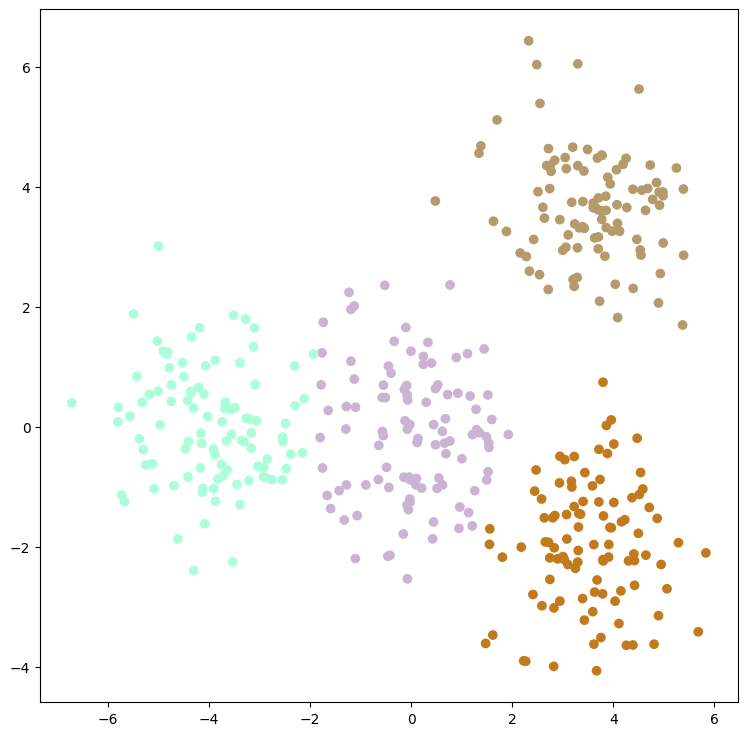

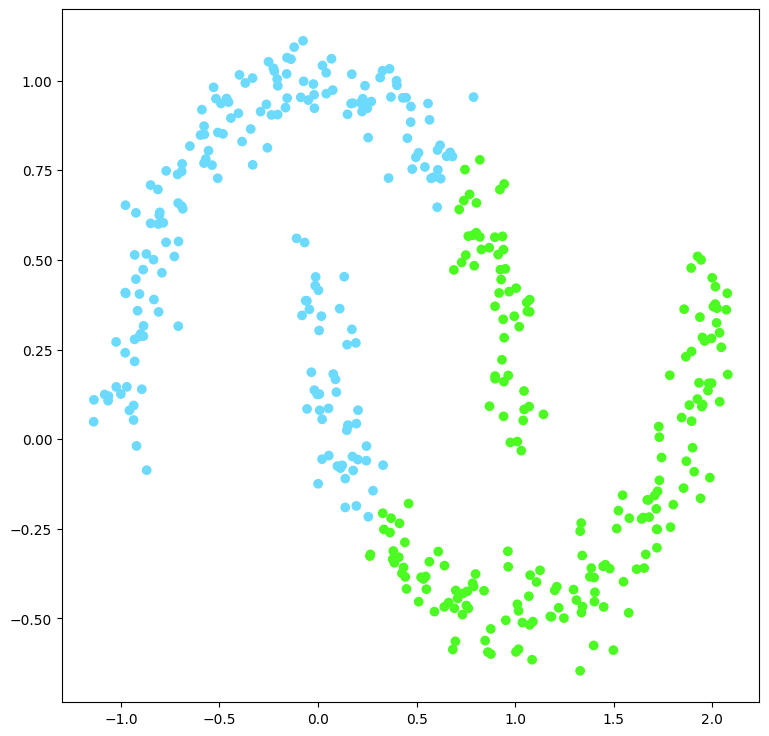

In [8]:
kmeans = KMeans(n_clusters=4, init="kmeans++")
kmeans.fit(X_1)
labels = kmeans.predict(X_1)
visualize_clusters(X_1, labels)

kmeans = KMeans(n_clusters=2, init="kmeans++")
kmeans.fit(X_2)
labels = kmeans.predict(X_2)
visualize_clusters(X_2, labels)

## DBScan (3 балла)
В отличие от K-means, DBScan не позволяет задать количество кластеров, на которое будут разбиты данные. Руководствуясь геометрической интерпретацией, он позволяет выделять кластеры более сложной формы.

**Описание методов**

`fit_predict(X, y=None)` для каждого элемента `X` возвращает метку кластера, к которому он относится.

**Возможные метрики**

`euclidean`, `manhattan`, `chebyshev`

Для быстрого поиска соседей используйте `sklearn.neighbors.KDTree`

In [9]:
from sklearn.neighbors import NearestNeighbors
import collections

class DBScan:
    _known_metric_functions: Dict[str, Callable] = {
        "euclidean": get_euclidean_distances,
        "manhattan": get_manhattan_distances,
        "chebyshev": get_chebyshev_distance,
    }
    
    NOISE = -1
    UNCLASSIFIED = -2

    def __init__(self, eps: float = 0.2, min_samples: int = 5, leaf_size: int = 40, metric: str = "euclidean"):
        """DBScan clusterization

        Args:
            eps, min_samples: parameters for selecting core samples.
                Core samples is a samples with at least `min_samples` samples in their `eps`-neighborhood
            metric: metric to use to calculate distance between samples, one of "euclidian", "manhattan", "chebyshev"
            leaf_size: minimum leaf size for KDTree.
        """

        self._eps = eps
        self._min_samples = min_samples
        if metric not in self._known_metric_functions:
            raise ValueError(f"Unknown metric function: {metric}")
        self._metric = metric
        self._get_distance = self._known_metric_functions[metric]
        self._kdtree_leaf_size = leaf_size

    def fit_predict(self, x: ndarray, y=None) -> ndarray:
        """Cluterize and return index for each point in x

        Args:
            x: input points, array of [n_points; dim]
            y: ignored, to mactch sklearn behaviour
        Return
            labels: cluster ids, array of [n_points]
        """
        
        n_samples = x.shape[0]
        if n_samples == 0:
            return np.array([], dtype=int)

        labels = np.full(n_samples, self.UNCLASSIFIED, dtype=int)
        
        nn_searcher = NearestNeighbors(
            radius=self._eps,
            algorithm='kd_tree',
            leaf_size=self._kdtree_leaf_size,
            metric=self._metric,
            n_jobs=-1
        )
        nn_searcher.fit(x)

        current_cluster_id = -1

        for i in range(n_samples):
            if labels[i] != self.UNCLASSIFIED:
                continue

            neighbor_indices: ndarray = nn_searcher.radius_neighbors(x[i:i+1], return_distance=False)[0]

            if len(neighbor_indices) < self._min_samples:
                labels[i] = self.NOISE
                continue
            
            current_cluster_id += 1
            labels[i] = current_cluster_id
            
            seeds = collections.deque(neighbor_indices)

            while seeds:
                current_point_idx = seeds.popleft()

                if labels[current_point_idx] == self.NOISE:
                    labels[current_point_idx] = current_cluster_id
                
                if labels[current_point_idx] != self.UNCLASSIFIED:
                    if labels[current_point_idx] != current_cluster_id and labels[current_point_idx] != self.UNCLASSIFIED:
                         continue 

                if labels[current_point_idx] == self.UNCLASSIFIED:
                     labels[current_point_idx] = current_cluster_id

                current_point_neighbor_indices: ndarray = nn_searcher.radius_neighbors(x[current_point_idx:current_point_idx+1], return_distance=False)[0]
                
                if len(current_point_neighbor_indices) >= self._min_samples:
                    for neighbor_idx in current_point_neighbor_indices:
                        if labels[neighbor_idx] == self.UNCLASSIFIED:
                            labels[neighbor_idx] = current_cluster_id
                            seeds.append(neighbor_idx)
                        elif labels[neighbor_idx] == self.NOISE:
                            labels[neighbor_idx] = current_cluster_id
                            seeds.append(neighbor_idx)

        return labels

Протестируйте алгоритм на синтетических данных. При необходимости подберите гиперпараметры для достижения лучшего качества кластеризации.

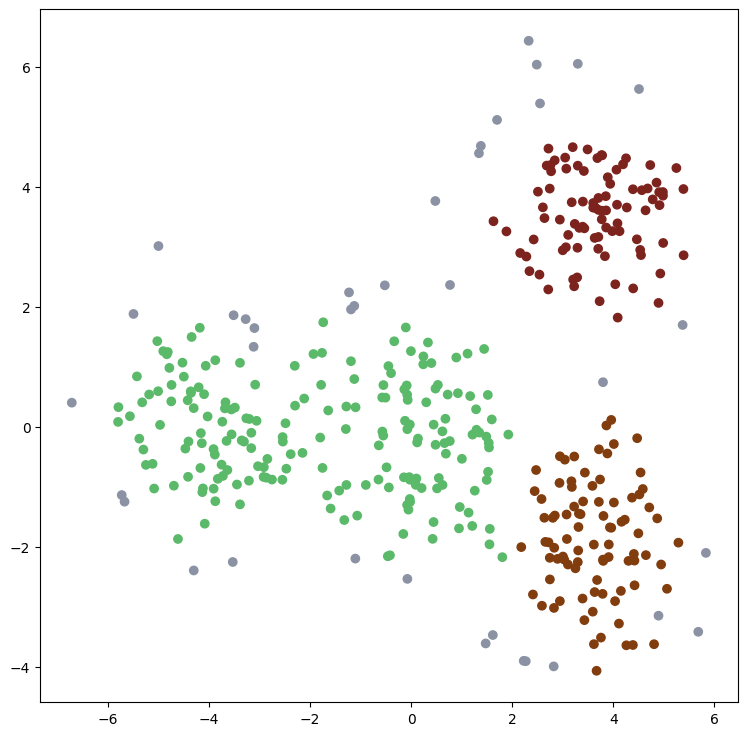

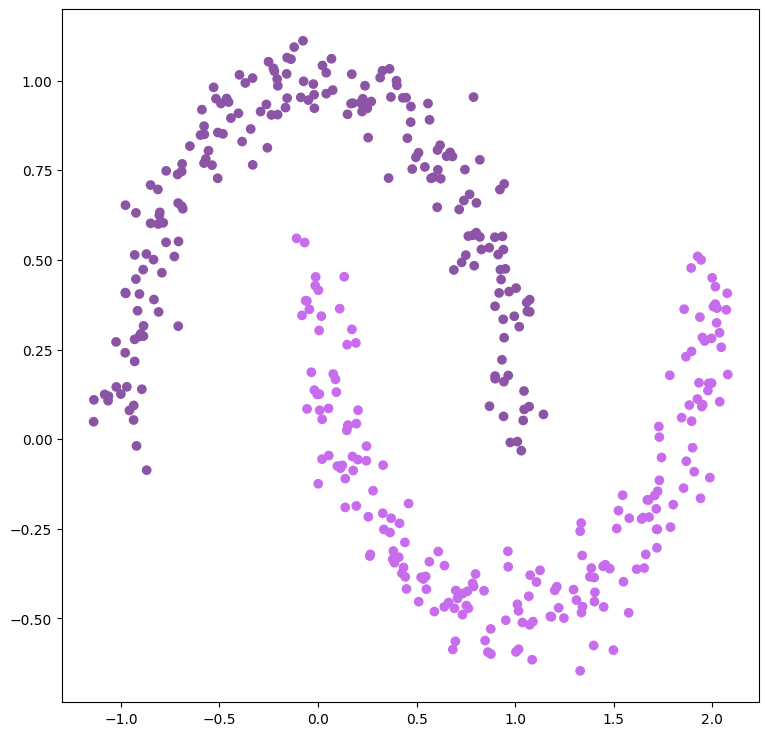

In [10]:
dbscan = DBScan(eps=0.6)
labels = dbscan.fit_predict(X_1)
visualize_clusters(X_1, labels)

dbscan = DBScan(eps=0.2)
labels = dbscan.fit_predict(X_2)
visualize_clusters(X_2, labels)

## Agglomerative Clustering (3 балла)
Идея AgglomerativeClustering заключается в том, чтобы итеративно объединять кластеры с наименьшим расстоянием между ними. Данный метод обладает высокой вычислительной сложностью, поэтому применим только для относительно небольших наборов данных.

**Описание методов**

`fit_predict(X, y=None)` для каждого элемента `X` возвращает метку кластера, к которому он относится.

### Linkage
__Linkage__ - это способ, которым будет рассчитываться расстояние между кластерами. Предлагается реализовать три варианта такой функции:
1. `average` - расстояние рассчитывается как среднее расстояние между всеми парами точек, где одна принадлежит первому кластеру, а другая - второму.
2. `single` - расстояние рассчитывается как минимальное из расстояний между всеми парами точек, где одна принадлежит первому кластеру, а другая - второму.
2. `complete` - расстояние рассчитывается как максимальное из расстояний между всеми парами точек, где одна принадлежит первому кластеру, а другая - второму.

Для быстрого вычисления воспользуемся формулой Ланса-Уильямса

$$
D(W, S) = \alpha_U D(U, S) + \alpha_V D(V, S) + \beta D(U, V) + \gamma \left| D(U, S) - D(V, S) \right|
$$


| Метод агломерации         | α<sub>U</sub>                             | α<sub>V</sub>                             | β                                       | γ       |
|--------------------------|------------------------------------------|------------------------------------------|-----------------------------------------|----------|
| Single linkage           | 0.5                                      | 0.5                                      | 0                                       | -0.5     |
| Complete linkage         | 0.5                                      | 0.5                                      | 0                                       | +0.5     |
| Average linkage          | n<sub>U</sub> / (n<sub>U</sub> + n<sub>V</sub>) | n<sub>V</sub> / (n<sub>U</sub> + n<sub>V</sub>) | 0                                       | 0        |
| Centroid linkage         | n<sub>U</sub> / (n<sub>U</sub> + n<sub>V</sub>) | n<sub>V</sub> / (n<sub>U</sub> + n<sub>V</sub>) | -n<sub>U</sub>n<sub>V</sub> / (n<sub>U</sub> + n<sub>V</sub>)² | 0        |
| Ward's method            | (n<sub>S</sub> + n<sub>U</sub>) / (n<sub>S</sub> + n<sub>U</sub> + n<sub>V</sub>) | (n<sub>S</sub> + n<sub>V</sub>) / (n<sub>S</sub> + n<sub>U</sub> + n<sub>V</sub>) | -n<sub>S</sub> / (n<sub>S</sub> + n<sub>U</sub> + n<sub>V</sub>) | 0        |

In [11]:
# Return coefficients based on Lance–Williams formula for different linkages


def get_average_linkage_params(u_size: int, v_size: int) -> Tuple[float, float, float, float]:
    sizes_sum = u_size + v_size
    return (u_size / sizes_sum, v_size / sizes_sum, 0, 0)


def get_single_linkage_params(u_size: int, v_size: int) -> Tuple[float, float, float, float]:
    return (0.5, 0.5, 0, -0.5)
    

def get_complete_linkage_params(u_size: int, v_size: int) -> Tuple[float, float, float, float]:
    return (0.5, 0.5, 0, 0.5)

In [12]:
from scipy.spatial.distance import pdist, squareform

class AgglomerativeClustering:

    _known_linkages = {
        "average": get_average_linkage_params,
        "single": get_single_linkage_params,
        "complete": get_complete_linkage_params,
    }

    def __init__(self, n_clusters: int = 16, linkage: str = "average"):
        """Agglomerative clusterization

        Args:
            n_clusters: number of clusters
            linkage: linkage to use, one of "average", "single", and "complete"
        """
        self._n_clusters = n_clusters
        if linkage not in self._known_linkages:
            raise ValueError(f"Unknown linkage: {linkage}")
        self._linkage = self._known_linkages[linkage]

    def fit_predict(self, x: ndarray, y=None) -> ndarray:
        """Cluterize and return index for each point in x

        Args:
            x: input points, array of [n_points; dim]
            y: ignored, to mactch sklearn behaviour
        Return
            labels: cluster ids, array of [n_points]
        """

        n_samples = x.shape[0]

        if n_samples == 0:
            return np.array([], dtype=int)

        effective_n_clusters = min(self._n_clusters, n_samples)
        if effective_n_clusters == 0 and n_samples > 0 : 
             effective_n_clusters = 1

        dist_matrix = squareform(pdist(x, metric='euclidean'))
        np.fill_diagonal(dist_matrix, np.inf)

        clusters_content: List[List[int]] = [[i] for i in range(n_samples)]
        cluster_sizes = np.ones(n_samples, dtype=int) 
        
        active_clusters_mask = np.ones(n_samples, dtype=bool)
        current_n_clusters = n_samples

        while current_n_clusters > effective_n_clusters:
            if current_n_clusters <= 1:
                break

            min_dist_val = np.inf
            c1_idx, c2_idx = -1, -1

            active_indices = np.where(active_clusters_mask)[0]
            if len(active_indices) < 2:
                break
            
            sub_dist_matrix = dist_matrix[np.ix_(active_indices, active_indices)]
            
            if sub_dist_matrix.size == 0:
                 break
            
            current_min_in_sub = np.min(sub_dist_matrix)
            if not np.isfinite(current_min_in_sub):
                break 

            relative_flat_idx = np.argmin(sub_dist_matrix)
            rel_c1, rel_c2 = np.unravel_index(relative_flat_idx, sub_dist_matrix.shape)

            c1_idx = active_indices[rel_c1]
            c2_idx = active_indices[rel_c2]
            min_dist_val = dist_matrix[c1_idx, c2_idx]

            if c1_idx > c2_idx:
                c1_idx, c2_idx = c2_idx, c1_idx
            
            alpha_i, alpha_j, beta, gamma = self._linkage(cluster_sizes[c1_idx], cluster_sizes[c2_idx])

            clusters_content[c1_idx].extend(clusters_content[c2_idx])
            clusters_content[c2_idx] = []

            for k_orig_idx in active_indices: 
                if k_orig_idx != c1_idx and k_orig_idx != c2_idx:
                    dist_c1_k = dist_matrix[c1_idx, k_orig_idx]
                    dist_c2_k = dist_matrix[c2_idx, k_orig_idx]
                    
                    new_dist_to_k = (alpha_i * dist_c1_k +
                                     alpha_j * dist_c2_k +
                                     beta * min_dist_val + 
                                     gamma * np.abs(dist_c1_k - dist_c2_k))
                    
                    dist_matrix[c1_idx, k_orig_idx] = new_dist_to_k
                    dist_matrix[k_orig_idx, c1_idx] = new_dist_to_k
            
            cluster_sizes[c1_idx] += cluster_sizes[c2_idx]
            cluster_sizes[c2_idx] = 0

            active_clusters_mask[c2_idx] = False
            
            dist_matrix[c2_idx, :] = np.inf
            dist_matrix[:, c2_idx] = np.inf
            
            dist_matrix[c1_idx, c1_idx] = np.inf 

            current_n_clusters -= 1
        
        labels = np.zeros(n_samples, dtype=int)
    
        final_active_cluster_original_indices = np.where(active_clusters_mask)[0]
        
        for new_label_id, original_cluster_idx in enumerate(final_active_cluster_original_indices):
            for point_original_idx in clusters_content[original_cluster_idx]:
                labels[point_original_idx] = new_label_id
            
        return labels

Протестируйте алгоритм на синтетических данных. При необходимости подберите гиперпараметры для достижения лучшего качества кластеризации.

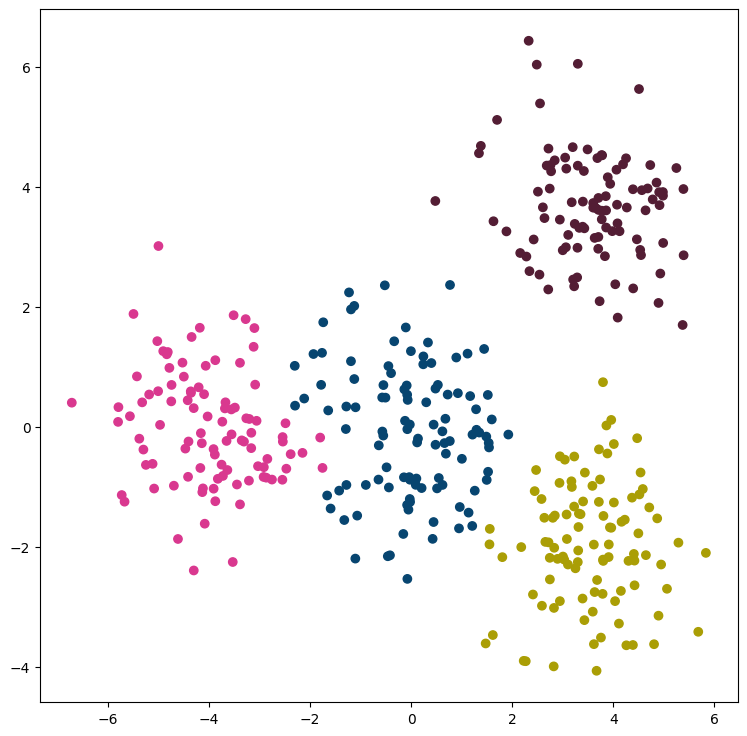

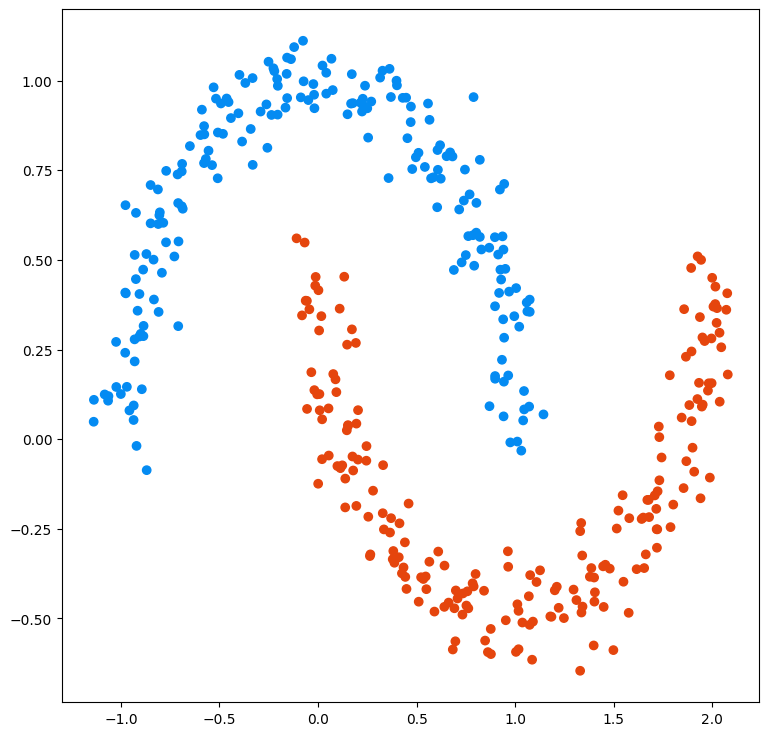

In [21]:
agg_clustering = AgglomerativeClustering(4, "complete")
labels = agg_clustering.fit_predict(X_1)
visualize_clusters(X_1, labels)

agg_clustering = AgglomerativeClustering(2, "single")
labels = agg_clustering.fit_predict(X_2)
visualize_clusters(X_2, labels)

## Сжатие изображений (1 балл)
Реализуйте методы считывания и записи изображения при помощи библиотеки [`Pillow`](https://github.com/python-pillow/Pillow).

Нормализованное изображение - это изображение, у которого все значения пикселей находятся в $[0; 1]$.

In [14]:
def read_image(path: str) -> ndarray:
    """Read and return image from file

    Args:
        path: path to the image file

    Return:
        image: normalized image array of shape [H, W, 3]
    """

    try:
        img_pil = Image.open(path)

        if img_pil.mode != 'RGB':
            img_pil = img_pil.convert('RGB')

        img_array = np.array(img_pil)

        if np.issubdtype(img_array.dtype, np.integer):
            max_value = np.iinfo(img_array.dtype).max
            normalized_image = img_array.astype(np.float32) / max_value
        elif np.issubdtype(img_array.dtype, np.floating):
            if img_array.min() >= 0.0 and img_array.max() <= 1.0:
                normalized_image = img_array.astype(np.float32)
            elif img_array.min() >= 0.0 and img_array.max() <= 255.0:
                normalized_image = img_array.astype(np.float32) / 255.0
            else:
                img_min = img_array.min()
                img_max = img_array.max()
                if img_max > 1.0:
                    normalized_image = img_array.astype(np.float32) / 255.0
                else:
                    normalized_image = img_array.astype(np.float32)
        else:
            raise TypeError(f"Неподдерживаемый тип данных изображения: {img_array.dtype} для файла {path}")

        if normalized_image.ndim != 3 or normalized_image.shape[2] != 3:
            raise ValueError(
                f"Изображение из {path} после обработки имеет форму {normalized_image.shape}. "
                f"Ожидалась форма (H, W, 3)."
            )
            
        return normalized_image
    
    except FileNotFoundError:
        raise FileNotFoundError(f"Ошибка: Файл изображения не найден по пути {path}")
    except Exception as e:
        raise RuntimeError(f"Ошибка при чтении или обработке изображения {path}: {e}")




def show_image(image: ndarray):
    """Display the image using matplotlib

    Args:
        image: normalized image array of shape [H, W, 3]
    """
    plt.figure(figsize=np.array(image.shape[:-1]) / 50)
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def save_image(image: ndarray, path: str):
    """Save the image to file

    Args:
        image: normalized image array of shape [H, W, 3]
        path: path to save the image
    """
    
    if not (isinstance(image, np.ndarray) and image.ndim == 3 and image.shape[2] == 3):
        raise ValueError(f"Ожидается NumPy массив формы [H, W, 3], получено: {type(image)}, форма {image.shape if isinstance(image, np.ndarray) else 'N/A'}")

    processed_image = np.clip(image, 0.0, 1.0)
    image_uint8 = (processed_image * 255.0).round().astype(np.uint8)
    
    try:
        pil_img = Image.fromarray(image_uint8, 'RGB')
        pil_img.save(path)
    except Exception as e:
        raise RuntimeError(f"Ошибка при сохранении изображения в {path}: {e}")

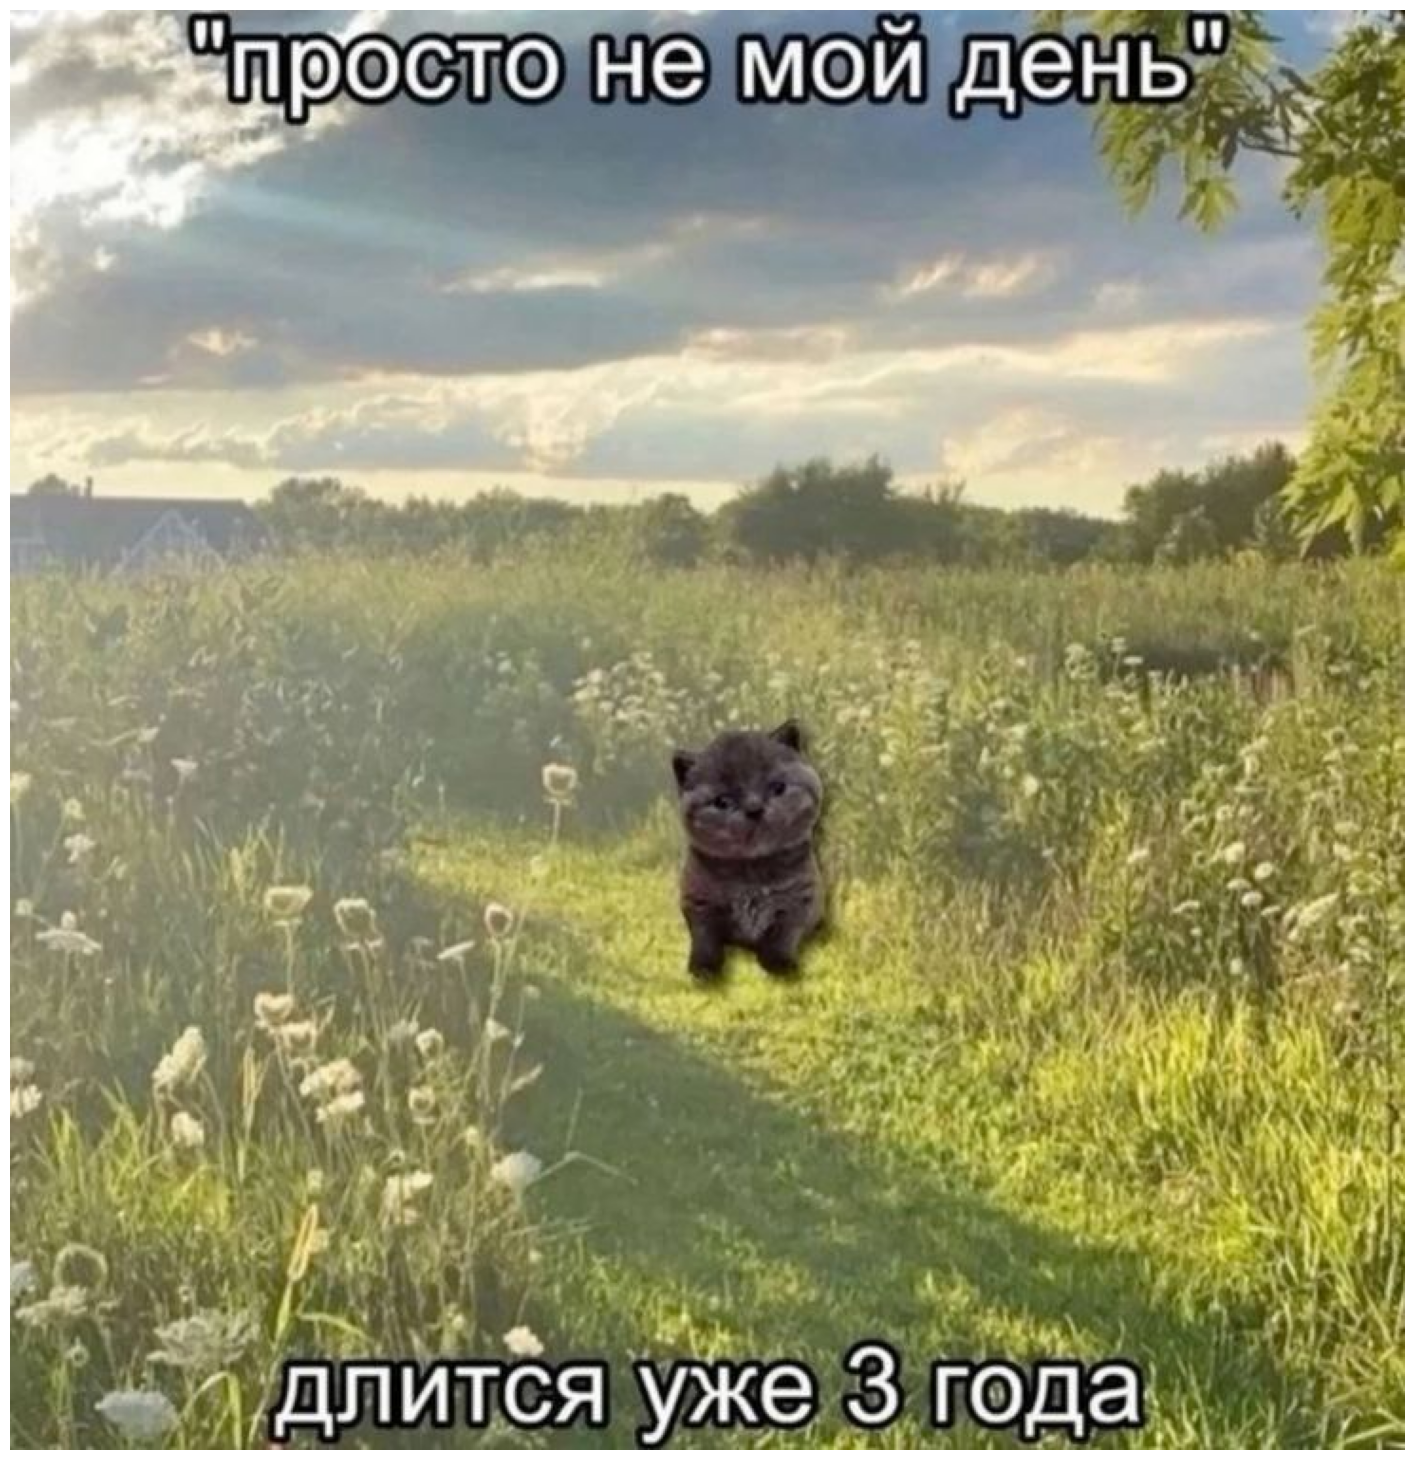

In [15]:
image = read_image("meme.jpg")
show_image(image)

Реализуйте функцию, которая будет кластеризовать цвета изображения одним из реализованных алгоритмов. Интерфейс этой функции можно менять. Функция должна возвращать новое изображение, в котором цвета заменены на цвета кластеров.

Затем примените ее к цветам изображения.

__Примечание: это задание проще всего выполнить при помощи KMeans__

In [16]:
def clusterize_image(image: ndarray, n_clusters: int):
    model = KMeans(n_clusters)
    model.fit(image.reshape(-1, 3))
    cluster_colors: np.ndarray = model._centroids
    clusters = model._cluster_ids_for_x_fit
    recolored = cluster_colors[clusters].reshape(image.shape)

    clusters_statistics(image.reshape(-1, 3), cluster_colors, clusters)  # Very slow (:
    return recolored

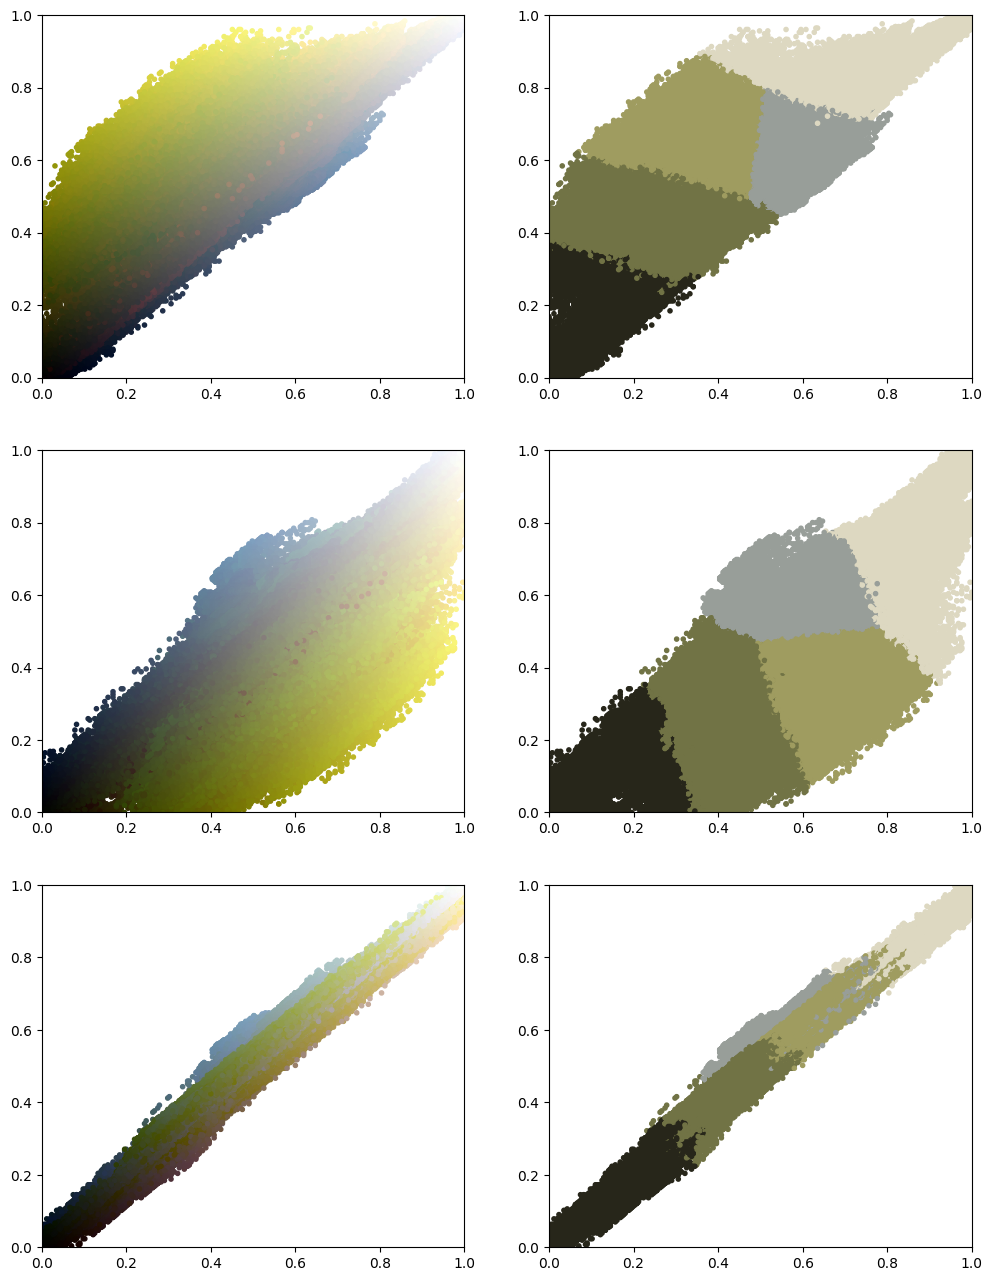

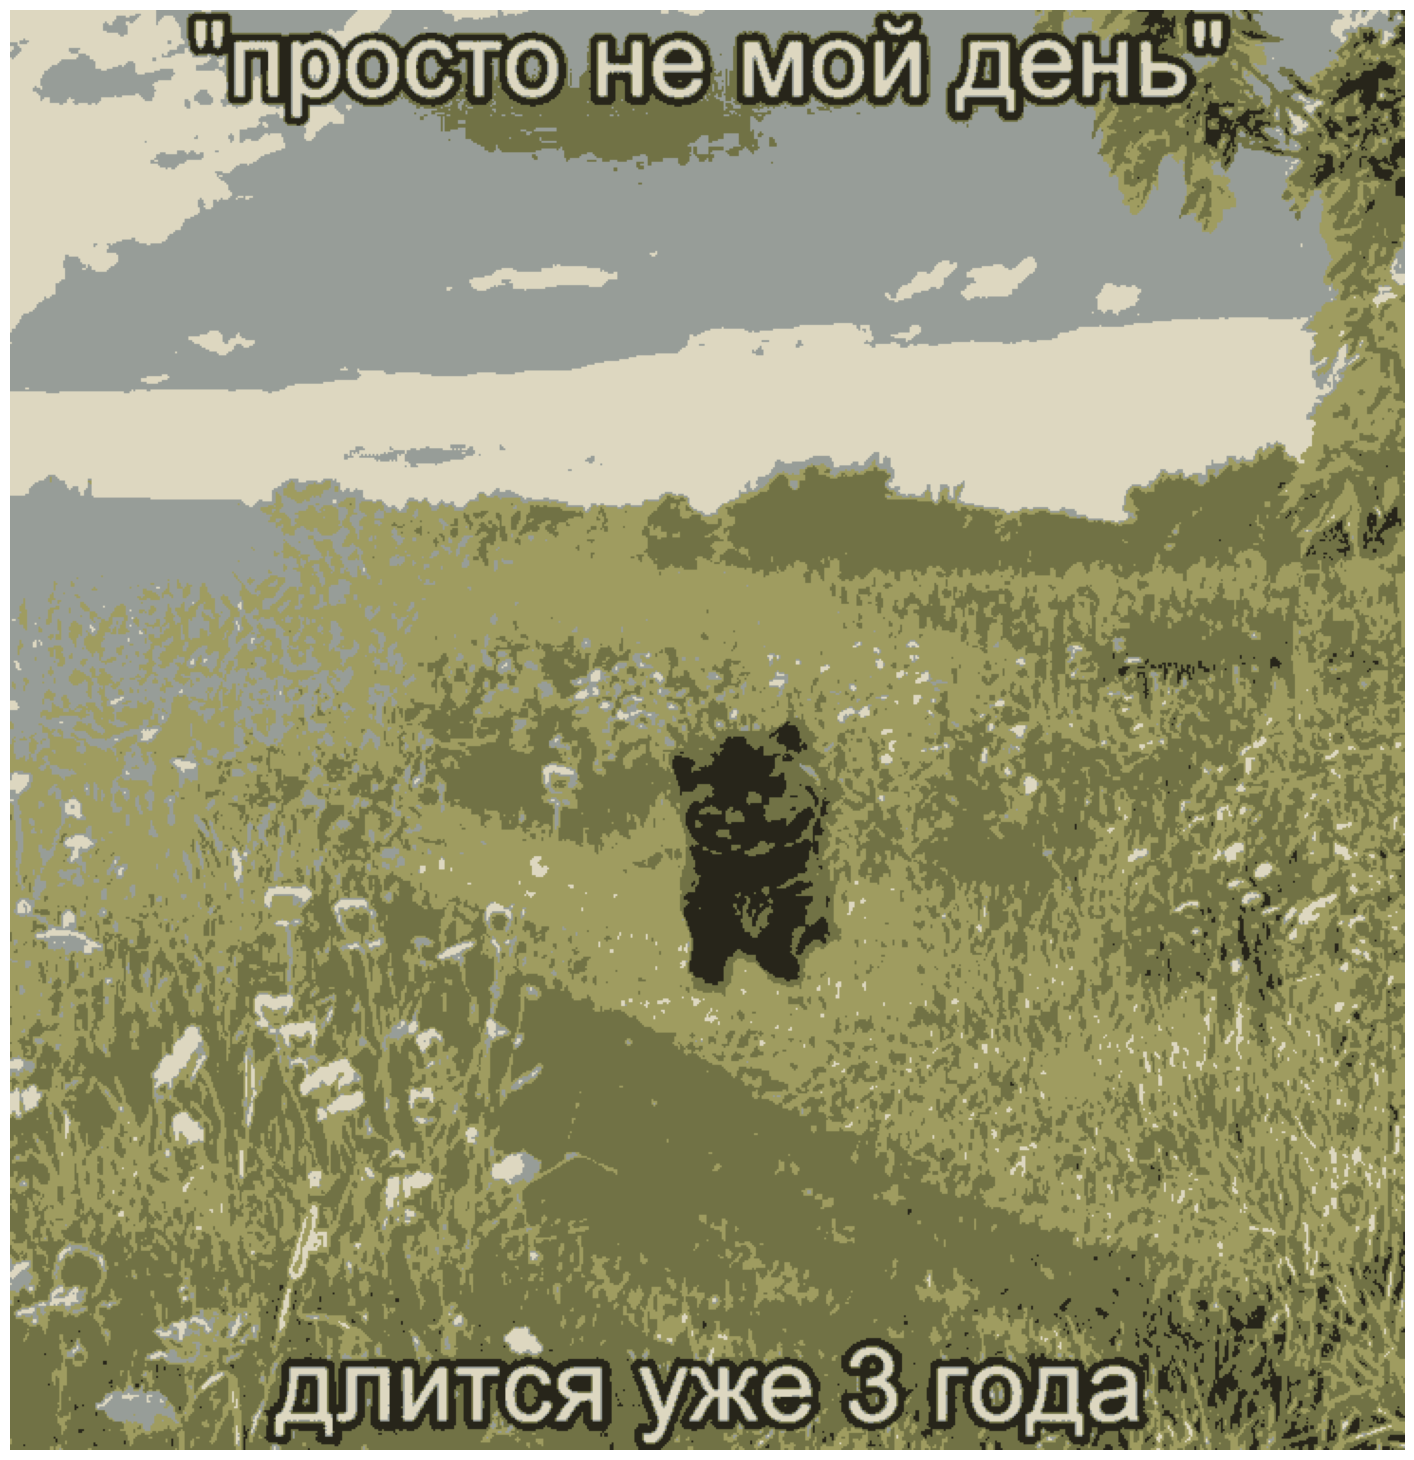

In [18]:
image = read_image("meme.jpg")
result = clusterize_image(image, 5)
show_image(result)
save_image(result, "result.jpg")